# The Autonomous Compliance Sentinel
## Goal 4

| Project | The Autonomous Compliance Sentinel |
| --- | --- |
| Modul | Responsible AI and Data Ethics |
| Authors | Group 2: Singh, Vikrant and Müller, Kay |

## What is this notebook?

This notebook runs the **Goal 4 agent**, the final piece of the Autonomous Compliance Sentinel. The agent reads an internal project proposal and checks whether it violates any of our nine Responsible AI policies (RAI-01 through RAI-09). If it does, the agent explains why, proposes a fix, asks a human to approve high-severity cases, and writes the result back to Confluence/Jira.

This is the **extended, pipeline-integrated** version. The logic lives in a tested `agent/` package; the notebook only imports it and shows the results step by step. Compared with the early prototype, the LLM tool-calling loop was replaced by a **deterministic LangGraph**.

## The full pipeline at a glance

```
Project proposal (text or PDF)
        |
        v
[Signal 1]  TF-IDF + Logistic Regression        (threshold 0.40)
        |
        |-- Compliant? --> STOP  (no action)
        |
        |-- Red Flag? --> continue
        v
[Signal 2]  RAG over the 9 RAI policies + XAI trigger words
        |          (multi-policy match  ->  governing severity)
        v
Verdict (LLM, offline template fallback)  +  open-ended check
        |
        |-- false alarm? --> cleared  (no action)
        |
        v
Human-in-the-loop gate   (High severity = a human must approve)
        |
        v
Writeback:  Confluence comment + Jira ticket + audit log
```

## Two signals, not one

| Signal | What it is | When it runs |
|--------|-----------|--------------|
| Signal 1 | TF-IDF + Logistic Regression, threshold 0.40 | Always, on every proposal |
| Signal 2 | RAG over the 9 policies + LLM verdict (offline fallback) | Only when Signal 1 flags a Red Flag |

Signal 1 is fast and cheap and makes the actual decision. Signal 2 is slower but grounds the reason and the fix in the real policy text.

## The 9 RAI policies

| Policy | Name | Severity |
|--------|------|----------|
| RAI-01 | Data Protection | High |
| RAI-02 | Transparency | High |
| RAI-03 | Fairness | High |
| RAI-04 | Human Dignity | High |
| RAI-05 | Prohibited Purpose | High |
| RAI-06 | Security | Medium |
| RAI-07 | Human Oversight | Medium |
| RAI-08 | Data Minimization | Medium |
| RAI-09 | Explainability | Medium |

The catalogue comes from Goal 1 (the severities can be overridden from `config/policies.csv`).

## 1. Setup

We import the `agent` package (the whole pipeline) and check which backend is active. Without a Groq key the verdict is phrased by a deterministic template (notebook still runs end to end).

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
from IPython.display import display

from agent import (Classifier, PolicyRetriever, build_graph, run_once,
                   run_batch, certify, groq_available, load_severity_overrides,
                   get_severity, extract_text)
from agent import loader

print("LLM backend       :", "Groq" if groq_available() else "offline fallback")
print("severity overrides:", load_severity_overrides())

LLM backend       : offline fallback
severity overrides: {'RAI-01': 'High', 'RAI-02': 'High', 'RAI-03': 'High', 'RAI-04': 'High', 'RAI-05': 'High', 'RAI-06': 'Medium', 'RAI-07': 'Medium', 'RAI-08': 'Medium', 'RAI-09': 'Medium'}


## 2. Weakness pre-gate (reuses Goal-3 `xai`)

Before trusting the model we run the Goal-3 weakness checks: negation robustness and the recall of the weakest policy. `certify()` turns them into a simple pass/fail. On the Version-2 model it deliberately reports `passed = False` because the model is negation-blind. That is the gate surfacing a documented weakness, not a bug.

In [15]:
certify()

{'negation_blind_pairs': 4,
 'negation_ok': False,
 'worst_policy': 'RAI-08',
 'worst_policy_recall': 0.722,
 'worst_policy_ok': True,
 'available': True,
 'passed': False}

## 3. The two signals in action

Signal 1 gives the Red-Flag probability and the **trigger words** (tfidf × coefficient) that drove it (this is our XAI grounding). Signal 2 takes those words as a query and retrieves the most relevant RAI policies with a match score.

In [16]:
clf = Classifier(loader.load_model("tfidf+logreg"))
rag = PolicyRetriever()

proposal = ("Our chatbot will handle customer complaints automatically "
            "without telling users it is an AI.")

print("Signal 1  (classifier)")
print("  Red-Flag probability:", round(clf.proba(proposal), 4))
print("  decision at 0.40    :", "Red Flag" if clf.predict(proposal) else "Compliant")

triggers = clf.trigger_words(proposal, n=8)
print("\nSignal 1 (XAI): trigger words")
display(pd.DataFrame(triggers, columns=["trigger word", "contribution"]))

print("Signal 2 (RAG): most relevant policies")
hits = rag.search(" ".join(w for w, _ in triggers), k=5)
display(pd.DataFrame([{"policy_id": h["policy_id"],
                       "severity": get_severity(h["policy_id"]),
                       "score": h["score"]} for h in hits]))

Signal 1  (classifier)
  Red-Flag probability: 0.5127
  decision at 0.40    : Red Flag

Signal 1 (XAI): trigger words


,trigger word,contribution
0,users,0.143159
1,automatically,0.114941
2,ai,0.100733
3,complaints,-0.048848
4,handle,-0.042632
5,chatbot,-0.022061
6,customer,-0.004541


Signal 2 (RAG): most relevant policies


,policy_id,severity,score
0,RAI-02,High,0.4283
1,RAI-07,Medium,0.4004
2,RAI-05,High,0.3794
3,RAI-01,High,0.3707
4,RAI-04,High,0.3654


## 4. A multi-violation proposal (loaded from a PDF)

Real problem documents break several policies at once, and they usually arrive as a PDF. We load the AuroraScreen HR product sheet with `extract_text` (this also demonstrates the PDF-upload path) and run it through the agent.

This case is the whole reason for the multi-policy logic. By raw match score the **single top policy is RAI-07 Human Oversight (Medium)**. Our agent keeps **every** policy within 0.06 of the best match and gates on the **worst** severity among them ("governing severity"). Four High policies sit inside that margin, so the governing severity is **High** and the document must go to a human, with one finding per matched policy.

In [17]:
graph = build_graph(classifier=clf, retriever=rag,
                    approver=lambda s: True, verify=True)

SAMPLE_PDF = "samples/aurora_hr_screen_product_sheet.pdf"
aurora = extract_text(SAMPLE_PDF)
print("Loaded", len(aurora), "characters from", SAMPLE_PDF, "\n")

result = run_once(aurora, graph=graph, proposal_id="aurora_demo")

print("Prediction         :", "Red Flag" if result["y_pred"] else "Compliant",
      "(p =", str(result["proba"]) + ")")
print("Governing severity :", result["severity"])
print("Policies matched   :",
      ", ".join(m["policy_id"] + " (" + m["severity"] + ")"
               for m in result["matched_policies"]))
print("Human review needed:", result["human_required"])
print("\nFindings:")
for f in result["findings"]:
    print("  [" + f["policy_id"] + " / " + f["severity"] + "]")
    print("     reason:", f["reason"])
    print("     fix   :", f["recommended_fix"])
print("\nTransparency note  :", result["verdict"]["provenance"])
print("Final decision     :", result["final_decision"])

Loaded 2629 characters from samples/aurora_hr_screen_product_sheet.pdf 

Prediction         : Red Flag (p = 0.8508)
Governing severity : High
Policies matched   : RAI-03 (High), RAI-05 (High), RAI-02 (High), RAI-04 (High), RAI-07 (Medium)
Human review needed: True

Findings:
  [RAI-03 / High]
     reason: The proposal is missing the safeguards for RAI-03; the wording around 'applicants, compliance, public, automated' drove the Red-Flag decision.
     fix   : Add the control required by RAI-03 and state it explicitly in the proposal.
  [RAI-05 / High]
     reason: The proposal is missing the safeguards for RAI-05; the wording around 'applicants, compliance, public, automated' drove the Red-Flag decision.
     fix   : Add the control required by RAI-05 and state it explicitly in the proposal.
  [RAI-02 / High]
     reason: The proposal is missing the safeguards for RAI-02; the wording around 'applicants, compliance, public, automated' drove the Red-Flag decision.
     fix   : Add the con

## 5. Analysis charts (A1–A3)

The same figures the Streamlit UI shows, rendered here from `charts.py`:

- **A3 — Red-Flag probability** against the 0.40 threshold.
- **A1 — trigger words**: the signed word contributions (red pushes toward Red Flag).
- **A2 — policy match scores**: one bar per policy, coloured by severity, with the match cutoff. The single top bar is the *Medium* policy RAI-07 — exactly why gating on the top hit alone would be wrong and the multi-policy gate is needed.

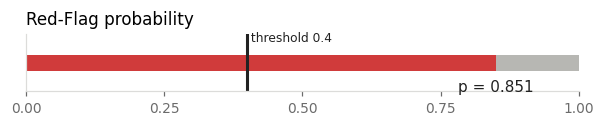

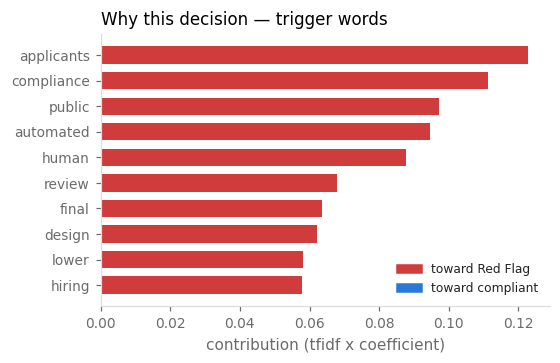

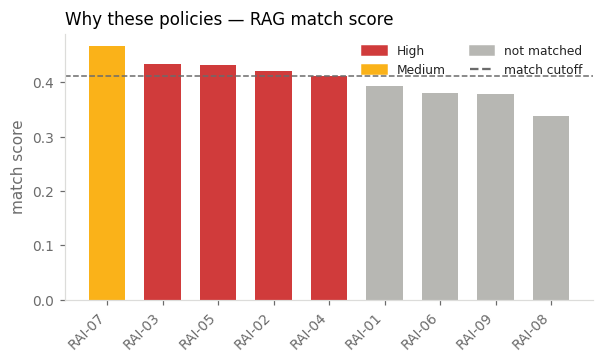

In [18]:
import charts
from io import BytesIO
from IPython.display import Image
import matplotlib.pyplot as plt

def show(fig):
    fig.patch.set_facecolor('white')
    fig.patch.set_alpha(1.0)
    for ax in fig.axes:
        ax.set_facecolor('white')
        ax.patch.set_facecolor('white')
        ax.patch.set_alpha(1.0)
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight", facecolor="white", transparent=False)
    plt.close(fig)
    display(Image(data=buf.getvalue()))

ink = charts.light_ink()
show(charts.fig_probability(result["proba"], threshold=0.40, ink=ink))
show(charts.fig_trigger_words(result["trigger_words"], ink=ink))
severities = {h["policy_id"]: get_severity(h["policy_id"]) for h in result["retrieved"]}
matched_ids = [m["policy_id"] for m in result["matched_policies"]]
show(charts.fig_policy_scores(result["retrieved"], matched_ids, severities, ink=ink))


## 6. A compliant proposal

The agent does not flag everything. With open-ended verification on, a benign proposal is cleared instead of forced into a violation.

In [19]:
compliant = ("The response time of general student management tasks shall take no "
             "longer than 5 seconds and the response time of scheduling tasks shall "
             "take no longer than 10 seconds.")
res_ok = run_once(compliant, graph=graph, proposal_id="compliant_demo")

print("Prediction    :", "Red Flag" if res_ok["y_pred"] else "Compliant")
print("Probability   :", res_ok["proba"])
print("Is violation  :", res_ok["is_violation"])
print("Final decision:", res_ok["final_decision"])

Prediction    : Compliant
Probability   : 0.2849
Is violation  : False
Final decision: Compliant - no action required.


## 7. Batch over the inbox + writeback

`run_batch` assesses every `*.txt` in `inbox/` and writes the artefacts to `outbox/`. The summary table shows the decisions; below it we print one generated Confluence comment and the last line of the audit log so the "write back into Confluence/Jira" step is concrete.

In [20]:
summary = run_batch(writeback=True)
pd.DataFrame(summary)[["proposal_id", "prediction", "proba",
                       "policy_id", "severity", "is_violation"]]

,proposal_id,prediction,proba,policy_id,severity,is_violation
0,proposal_01_ai_chatbot,Red Flag,0.5127,RAI-02,High,True
1,proposal_02_scoring,Red Flag,0.5573,RAI-05,High,True
2,proposal_03_normal_feature,Red Flag,0.5619,RAI-05,High,True
3,proposal_04_no_oversight,Red Flag,0.7144,RAI-07,Medium,True


In [21]:
import os, glob, json

comment = sorted(glob.glob(os.path.join("outbox", "*_confluence_comment.md")))[0]
print("----- " + os.path.basename(comment) + " -----")
print(open(comment, encoding="utf-8").read())

with open(os.path.join("outbox", "agent_log.jsonl"), encoding="utf-8") as fh:
    last = fh.readlines()[-1]
print("----- agent_log.jsonl (last entry) -----")
print(json.dumps(json.loads(last), indent=2))

----- manual_run_confluence_comment.md -----
# Compliance Sentinel - manual_run

- **Prediction:** Red Flag
- **Probability:** 0.5127
- **Policy:** RAI-02 (High)
- **Reason:** The proposal is missing the safeguards for RAI-02; the wording around 'users, automatically, ai' drove the Red-Flag decision.
- **Recommended fix:** Add the control required by RAI-02 and state it explicitly in the proposal.
- **Decision:** High severity (RAI-02): human reviewer rejected. No changes made.

----- agent_log.jsonl (last entry) -----
{
  "predicted": 1,
  "probability": 0.7144,
  "policy_id": "RAI-07",
  "matched_policies": [
    "RAI-07"
  ],
  "governing_severity": "Medium",
  "is_violation": true,
  "trigger_words": [
    "human",
    "decision",
    "human loop",
    "loop",
    "fully",
    "automatically",
    "automatically human",
    "fully automatically"
  ],
  "verdict_source": "offline",
  "human_approved": true,
  "proposal_id": "proposal_04_no_oversight",
  "timestamp": "2026-07-19T23:2

## 8. UI options

**Streamlit** (web): `streamlit run streamlit_app.py` — PDF upload, findings, the A1–A3 charts and real APPROVE/REJECT buttons.

## Conclusion

The extended agent runs the full concept end to end. It certifies the model, uses two signals (a fast classifier plus RAG-grounded policies), reports **every** matched policy and gates on the governing severity, verifies open-endedly instead of assuming a violation, routes only borderline cases to the LLM, writes real Confluence/Jira/audit artefacts, runs in batch, reads PDFs and exposes a UI.

The Pseudo-Model-Card below records the model's limitations, biases, attacks and restrictions.

---

## Pseudo Model Card (English) - System / Agent Card - Compliance Sentinel Agent

**Project:** The Autonomous Compliance Sentinel &middot; **Module:** Responsible AI and Data Ethics &middot; **Group 2:** Singh, Vikrant and Müller, Kay

### 1. System details
- **System:** LangGraph agent (classify -> assess -> human_gate; extended with compliant, cleared and writeback).
- **Components:** Goal-2 model as gatekeeper (TF-IDF + LogReg, threshold 0.40) &middot; RAG over 9 RAI policies (semantic: HuggingFace embeddings + Chroma; fallback: TF-IDF keyword) &middot; multi-policy gate with a governing severity (High beats Medium) &middot; LLM verdict (Groq) with a deterministic offline template as fallback &middot; writeback: Confluence comment, Jira ticket, audit log.

### 2. Intended use
- **In scope:** autonomous monitoring of project documentation for RAI and transparency violations; suggesting fixes and writing back to Confluence/Jira.
- **Out of scope:** automatic sign-off of "High" cases without human approval.

### 3. Model vs. LLM split (provenance transparency)
- **Decision (Red Flag yes/no) = model** - deterministic and testable.
- **Reason and fix = LLM** (or the offline template) - wording only, may be wrong.
- Every output carries a note: the Red-Flag decision comes from the trained model; the reason and fix may be inaccurate - please verify before acting.

### 4. Limitations
- Inherits all model weaknesses from Goal 3 (negation blindness, weak RAI-08, low precision / false alarms).
- The LLM may hallucinate reasons; the RAG semantics fall back to a keyword search offline.
- Writeback writes local mock files (no real Confluence/Jira API call).

### 5. Bias
- Carries the data and model bias from Goals 1 to 3 (synthetic vs. real Red Flags, group recall gaps).

### 6. Attacks / Robustness
- **Prompt injection:** the proposal text flows into the LLM prompt - a manipulated text could influence the reason (the decision stays with the model).
- **Evasion:** the model is robust to masking (Goal 3) but negation-blind.
- **Weakness pre-gate:** `certify()` checks the model against the Goal-3 weaknesses (negation, weakest policy) before it is used.

### 7. Restrictions (out of scope)
- Not legally binding; English proposals only; "High" severity requires human approval.
- Does not replace a legal or expert compliance review but supports it.